# TP2: Text Mining
## Hany El Atlassi

### Étape 1 - Importer Scikit-learn

In [39]:
import sklearn
from sklearn.datasets import fetch_20newsgroups

### Étape 2 - Importer l'ensemble de données de Scikit-learn

In [40]:
data = fetch_20newsgroups()
print(type(data))

<class 'sklearn.utils._bunch.Bunch'>


In [41]:
print(dir(data))

['DESCR', 'data', 'filenames', 'target', 'target_names']


In [42]:
data.target

array([7, 4, 4, ..., 3, 1, 8])

In [43]:
data.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [44]:
data.data[:2]

["From: lerxst@wam.umd.edu (where's my thing)\nSubject: WHAT car is this!?\nNntp-Posting-Host: rac3.wam.umd.edu\nOrganization: University of Maryland, College Park\nLines: 15\n\n I was wondering if anyone out there could enlighten me on this car I saw\nthe other day. It was a 2-door sports car, looked to be from the late 60s/\nearly 70s. It was called a Bricklin. The doors were really small. In addition,\nthe front bumper was separate from the rest of the body. This is \nall I know. If anyone can tellme a model name, engine specs, years\nof production, where this car is made, history, or whatever info you\nhave on this funky looking car, please e-mail.\n\nThanks,\n- IL\n   ---- brought to you by your neighborhood Lerxst ----\n\n\n\n\n",
 "From: guykuo@carson.u.washington.edu (Guy Kuo)\nSubject: SI Clock Poll - Final Call\nSummary: Final call for SI clock reports\nKeywords: SI,acceleration,clock,upgrade\nArticle-I.D.: shelley.1qvfo9INNc3s\nOrganization: University of Washington\nLines: 

In [45]:
for i in range(20):
    print("Classe: %s, Nombre textes: %s" % (i,len(data.target[data.target==i])))

Classe: 0, Nombre textes: 480
Classe: 1, Nombre textes: 584
Classe: 2, Nombre textes: 591
Classe: 3, Nombre textes: 590
Classe: 4, Nombre textes: 578
Classe: 5, Nombre textes: 593
Classe: 6, Nombre textes: 585
Classe: 7, Nombre textes: 594
Classe: 8, Nombre textes: 598
Classe: 9, Nombre textes: 597
Classe: 10, Nombre textes: 600
Classe: 11, Nombre textes: 595
Classe: 12, Nombre textes: 591
Classe: 13, Nombre textes: 594
Classe: 14, Nombre textes: 593
Classe: 15, Nombre textes: 599
Classe: 16, Nombre textes: 546
Classe: 17, Nombre textes: 564
Classe: 18, Nombre textes: 465
Classe: 19, Nombre textes: 377


In [46]:
len(data.target)

11314

In [47]:
categories = ["comp.os.ms-windows.misc", "comp.sys.ibm.pc.hardware", "comp.sys.mac.hardware", "comp.windows.x"]

In [48]:
dataset = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)

In [49]:
dataset.target_names

['comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x']

In [50]:
for i in range(4):
    print("Classe: %s, Nombre textes: %s" % (i,len(data.target[data.target==i])))

Classe: 0, Nombre textes: 480
Classe: 1, Nombre textes: 584
Classe: 2, Nombre textes: 591
Classe: 3, Nombre textes: 590


### Étape 3 - Organisation de données

In [51]:
from sklearn.feature_extraction.text import CountVectorizer
count_vect = CountVectorizer()
x_train_counts = count_vect.fit_transform(dataset.data)
x_train_counts.shape

(2352, 60987)

In [52]:
count_vect.vocabulary_.get(u'os')

42292

In [53]:
count_vect.vocabulary_.get(u'mac')

36430

In [54]:
from sklearn.feature_extraction.text import TfidfTransformer
tf_transformer = TfidfTransformer(use_idf=False).fit(x_train_counts)
x_train_tf = tf_transformer.transform(x_train_counts)
x_train_tf.shape

(2352, 60987)

In [55]:
tfidf_transformer = TfidfTransformer()
x_train_tfidf = tfidf_transformer.fit_transform(x_train_counts)
x_train_tfidf.shape

(2352, 60987)

### Étape 4 - Construire le modèle

In [56]:
from sklearn.naive_bayes import MultinomialNB
clf = MultinomialNB().fit(x_train_tfidf, dataset.target)

In [57]:
docs_new = ["Mac est une machine qui utilise le system d''exploitation mac os", "OpenGL on the GPU is fast"]
x_new_counts = count_vect.transform(docs_new)
x_new_tfidf = tfidf_transformer.transform(x_new_counts)

predicted = clf.predict(x_new_tfidf)
for doc, category in zip(docs_new, predicted):
    print("%r => %s"%(doc,dataset.target_names[category]))

"Mac est une machine qui utilise le system d''exploitation mac os" => comp.sys.mac.hardware
'OpenGL on the GPU is fast' => comp.sys.ibm.pc.hardware


In [58]:
from sklearn.pipeline import Pipeline
text_clf = Pipeline([('vect', CountVectorizer()), ('tfidf', TfidfTransformer()), ('clf', MultinomialNB())])

In [59]:
text_clf.fit(dataset.data, dataset.target)

Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf', MultinomialNB())])

### Étape 5 - Évaluation du modèle et de sa précision

In [60]:
import numpy as np

text_clf.fit(dataset.data, dataset.target)
dataset_test = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=42)
docs_test = dataset_test.data
predicted = text_clf.predict(docs_test)
np.mean(predicted==dataset_test.target)

np.float64(0.834610472541507)

In [61]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(dataset_test.target, predicted, target_names=dataset_test.target_names))

                          precision    recall  f1-score   support

 comp.os.ms-windows.misc       0.84      0.73      0.78       394
comp.sys.ibm.pc.hardware       0.72      0.89      0.80       392
   comp.sys.mac.hardware       0.89      0.86      0.87       385
          comp.windows.x       0.93      0.85      0.89       395

                accuracy                           0.83      1566
               macro avg       0.84      0.83      0.84      1566
            weighted avg       0.84      0.83      0.84      1566



In [62]:
print(confusion_matrix(dataset_test.target, predicted))

[[289  71  15  19]
 [ 16 350  22   4]
 [ 13  39 331   2]
 [ 27  25   6 337]]


### Exercice

In [63]:
from sklearn import svm

svm_model = svm.SVC()

In [64]:
text_svm = Pipeline([('vect', CountVectorizer()), ('tfidf', TfidfTransformer()), ('svm', svm_model)])
text_svm.fit(dataset.data, dataset.target)

Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('svm', SVC())])

In [65]:
svm_predicted = text_svm.predict(docs_test)

In [66]:
print(classification_report(dataset_test.target, svm_predicted, target_names=dataset_test.target_names))

                          precision    recall  f1-score   support

 comp.os.ms-windows.misc       0.81      0.78      0.79       394
comp.sys.ibm.pc.hardware       0.77      0.85      0.81       392
   comp.sys.mac.hardware       0.88      0.89      0.88       385
          comp.windows.x       0.93      0.86      0.89       395

                accuracy                           0.84      1566
               macro avg       0.85      0.84      0.84      1566
            weighted avg       0.85      0.84      0.84      1566



In [67]:
print(confusion_matrix(dataset_test.target, svm_predicted))

[[306  58  15  15]
 [ 24 334  27   7]
 [  5  32 343   5]
 [ 41  10   6 338]]


In [68]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=3)
text_knn = Pipeline([('vect', CountVectorizer()), ('tfidf', TfidfTransformer()), ('svm', knn_model)])
text_knn.fit(dataset.data, dataset.target)


Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('svm', KNeighborsClassifier(n_neighbors=3))])

In [69]:
knn_predicted = text_knn.predict(docs_test)

In [70]:
print(classification_report(dataset_test.target, knn_predicted, target_names=dataset_test.target_names))

                          precision    recall  f1-score   support

 comp.os.ms-windows.misc       0.59      0.62      0.61       394
comp.sys.ibm.pc.hardware       0.68      0.67      0.68       392
   comp.sys.mac.hardware       0.77      0.64      0.70       385
          comp.windows.x       0.66      0.76      0.71       395

                accuracy                           0.67      1566
               macro avg       0.68      0.67      0.67      1566
            weighted avg       0.68      0.67      0.67      1566



In [71]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier()
text_dt = Pipeline([('vect', CountVectorizer()), ('tfidf', TfidfTransformer()), ('svm', dt_model)])
text_dt.fit(dataset.data, dataset.target)

Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('svm', DecisionTreeClassifier())])

In [72]:
dt_predicted = text_dt.predict(docs_test)
print(classification_report(dataset_test.target, dt_predicted, target_names=dataset_test.target_names))

                          precision    recall  f1-score   support

 comp.os.ms-windows.misc       0.63      0.71      0.67       394
comp.sys.ibm.pc.hardware       0.67      0.62      0.64       392
   comp.sys.mac.hardware       0.75      0.80      0.78       385
          comp.windows.x       0.70      0.62      0.66       395

                accuracy                           0.69      1566
               macro avg       0.69      0.69      0.69      1566
            weighted avg       0.69      0.69      0.68      1566



In [73]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd

results = {
    "Naive Bayes": predicted,
    "SVM": svm_predicted,
    "KNN": knn_predicted,
    "Decision Tree": dt_predicted,
}

comparison = []
for name, preds in results.items():
    accuracy = accuracy_score(dataset_test.target, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(dataset_test.target, preds, average="weighted")
    comparison.append({"Méthode": name, "Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1-score": f1})

comparison_df = pd.DataFrame(comparison).set_index("Méthode")
comparison_df

,Accuracy,Precision,Recall,F1-score
Méthode,,,,
Naive Bayes,0.834610,0.843799,0.834610,0.835591
SVM,0.843550,0.846644,0.843550,0.844100
KNN,0.672414,0.677637,0.672414,0.672636
Decision Tree,0.685824,0.686471,0.685824,0.684589


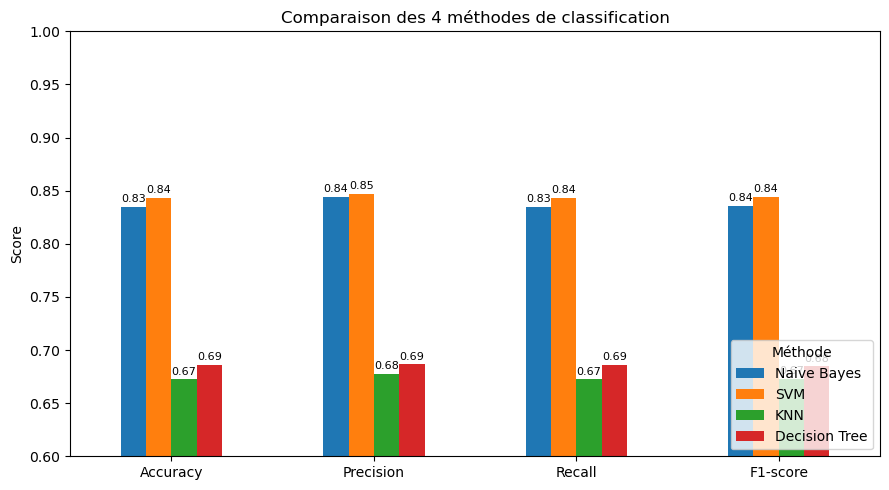

In [74]:
import matplotlib.pyplot as plt

ax = comparison_df.T.plot(kind="bar", figsize=(9, 5), rot=0)
plt.ylabel("Score")
plt.title("Comparaison des 4 méthodes de classification")
plt.ylim(0.6, 1.0)
plt.legend(title="Méthode", loc="lower right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()